## **Final Spreadsheet Prep and Computing Evaluation Metrics**

1) Loading the files

In [1]:
import pandas as pd

tfidf = pd.read_csv("TD-IDF_TestingResults.csv")
bm25 = pd.read_csv("BM25_Results.csv")
sbert = pd.read_csv("SBERT_Results.csv")
gt = pd.read_csv("GroundTruthLabeled(GroundTruth).csv", encoding="cp1252")

2) Cleaning the ground truth file keeping only the usable rows

In [2]:
gt["resume_preview"] = gt["resume_preview"].fillna("").astype(str).str.strip()
gt["judgeable"] = gt["resume_preview"] != ""
gt["labeled"] = gt["relevant"].notna()

gt_final = gt[(gt["judgeable"]) & (gt["labeled"])].copy()
gt_final["relevant"] = gt_final["relevant"].astype(int)

3) Cheking how many usable rows we have left

In [3]:
print("Original ground truth rows:", len(gt))
print("Usable labeled rows:", len(gt_final))
print("\nRelevant value counts:")
print(gt_final["relevant"].value_counts())

Original ground truth rows: 124
Usable labeled rows: 93

Relevant value counts:
relevant
0    78
1    15
Name: count, dtype: int64


4) Saving the updated ground truth spredsheet

In [4]:
gt_final.to_csv("GroundTruth_FinalVer.csv", index=False, encoding="utf-8-sig")

5) Merging the final version of the ground truth with the other model results

In [5]:
tfidf_eval = tfidf.merge(
    gt_final[["job_id", "resume_index", "relevant"]],
    on=["job_id", "resume_index"],
    how="inner"
)

bm25_eval = bm25.merge(
    gt_final[["job_id", "resume_index", "relevant"]],
    on=["job_id", "resume_index"],
    how="inner"
)

sbert_eval = sbert.merge(
    gt_final[["job_id", "resume_index", "relevant"]],
    on=["job_id", "resume_index"],
    how="inner"
)

6) Checking how much data the models have

In [6]:
print("TF-IDF judged rows:", len(tfidf_eval))
print("BM25 judged rows:", len(bm25_eval))
print("SBERT judged rows:", len(sbert_eval))

print("\nTF-IDF rows per job:")
print(tfidf_eval.groupby("job_id").size())

print("\nBM25 rows per job:")
print(bm25_eval.groupby("job_id").size())

print("\nSBERT rows per job:")
print(sbert_eval.groupby("job_id").size())

TF-IDF judged rows: 20
BM25 judged rows: 49
SBERT judged rows: 50

TF-IDF rows per job:
job_id
custom_0      6
dataset_0     3
dataset_24    3
dataset_6     4
dataset_82    4
dtype: int64

BM25 rows per job:
job_id
custom_0      10
dataset_0      9
dataset_24    10
dataset_6     10
dataset_82    10
dtype: int64

SBERT rows per job:
job_id
custom_0      10
dataset_0     10
dataset_24    10
dataset_6     10
dataset_82    10
dtype: int64


7) Computing simple evaluation metrics

*a)* *Judged Presicion*

In [7]:
def judged_precision(df):
    return df.groupby("job_id")["relevant"].mean()

print("TF-IDF judged precision:")
print(judged_precision(tfidf_eval))
print()

print("BM25 judged precision:")
print(judged_precision(bm25_eval))
print()

print("SBERT judged precision:")
print(judged_precision(sbert_eval))

#For Averages overall
print("TF-IDF mean judged precision:", judged_precision(tfidf_eval).mean())
print("BM25 mean judged precision:", judged_precision(bm25_eval).mean())
print("SBERT mean judged precision:", judged_precision(sbert_eval).mean())

TF-IDF judged precision:
job_id
custom_0      0.333333
dataset_0     0.333333
dataset_24    0.000000
dataset_6     0.500000
dataset_82    0.500000
Name: relevant, dtype: float64

BM25 judged precision:
job_id
custom_0      0.2
dataset_0     0.0
dataset_24    0.0
dataset_6     0.1
dataset_82    0.1
Name: relevant, dtype: float64

SBERT judged precision:
job_id
custom_0      0.5
dataset_0     0.2
dataset_24    0.1
dataset_6     0.3
dataset_82    0.2
Name: relevant, dtype: float64
TF-IDF mean judged precision: 0.3333333333333333
BM25 mean judged precision: 0.08
SBERT mean judged precision: 0.25999999999999995


*b)* *MRR*

In [8]:
def mrr(df):
    rr_scores = []
    for job_id, group in df.sort_values(["job_id", "rank"]).groupby("job_id"):
        rel = group[group["relevant"] == 1]
        if len(rel) == 0:
            rr_scores.append(0)
        else:
            first_rank = rel["rank"].iloc[0]
            rr_scores.append(1 / first_rank)
    return sum(rr_scores) / len(rr_scores)

print("TF-IDF MRR:", mrr(tfidf_eval))
print("BM25 MRR:", mrr(bm25_eval))
print("SBERT MRR:", mrr(sbert_eval))

TF-IDF MRR: 0.4619047619047619
BM25 MRR: 0.16190476190476188
SBERT MRR: 0.5


*c)* *Hit Rate*

In [9]:
def hit_rate(df):
    hits = (df.groupby("job_id")["relevant"].sum() > 0).astype(int)
    return hits.mean()

print("TF-IDF Hit Rate:", hit_rate(tfidf_eval))
print("BM25 Hit Rate:", hit_rate(bm25_eval))
print("SBERT Hit Rate:", hit_rate(sbert_eval))

TF-IDF Hit Rate: 0.8
BM25 Hit Rate: 0.6
SBERT Hit Rate: 1.0


8) Making a summary table for comparisons

In [10]:
summary = pd.DataFrame({
    "Model": ["TF-IDF", "BM25", "SBERT"],
    "Mean_Judged_Precision": [
        judged_precision(tfidf_eval).mean(),
        judged_precision(bm25_eval).mean(),
        judged_precision(sbert_eval).mean()
    ],
    "MRR": [
        mrr(tfidf_eval),
        mrr(bm25_eval),
        mrr(sbert_eval)
    ],
    "Hit_Rate": [
        hit_rate(tfidf_eval),
        hit_rate(bm25_eval),
        hit_rate(sbert_eval)
    ],
    "Judged_Rows": [
        len(tfidf_eval),
        len(bm25_eval),
        len(sbert_eval)
    ]
})

summary

,Model,Mean_Judged_Precision,MRR,Hit_Rate,Judged_Rows
0,TF-IDF,0.333333,0.461905,0.8,20
1,BM25,0.080000,0.161905,0.6,49
2,SBERT,0.260000,0.500000,1.0,50


9) Saving the final summary for the report

In [11]:
summary.to_csv("Evaluation_summary.csv", index=False)

10) Making a chart

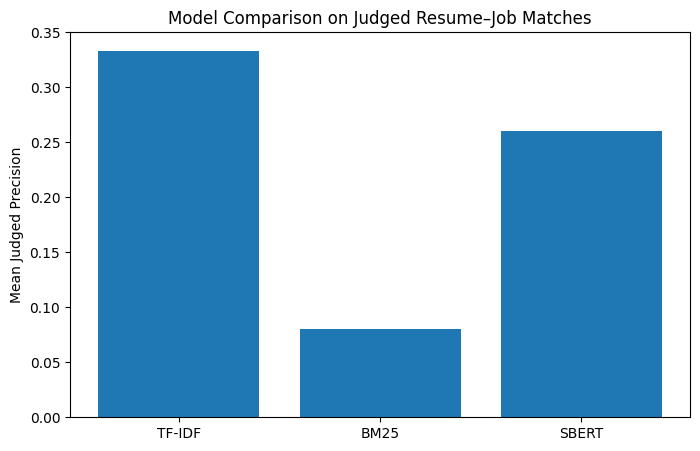

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(summary["Model"], summary["Mean_Judged_Precision"])
plt.ylabel("Mean Judged Precision")
plt.title("Model Comparison on Judged Resume–Job Matches")
plt.show()

11) Finally inspecting a few results

In [17]:
job = "custom_0"

print("TF-IDF")
display(
    tfidf_eval[tfidf_eval["job_id"] == job]
    .sort_values("rank")[[
        "rank", "resume_index", "resume_domain", "relevant"
    ]]
)

print("BM25")
display(
    bm25_eval[bm25_eval["job_id"] == job]
    .sort_values("rank")[[
        "rank", "resume_index", "resume_domain", "resume_preview", "relevant"
    ]]
)

print("SBERT")
display(
    sbert_eval[sbert_eval["job_id"] == job]
    .sort_values("rank")[[
        "rank", "resume_index", "resume_domain", "resume_preview", "relevant"
    ]]
)

TF-IDF


,rank,resume_index,resume_domain,relevant
14,1,249,Apparel,0
15,3,235,Apparel,0
16,5,287,Research Assistant,0
17,6,291,Research Assistant,1
18,9,254,Research Assistant,1
19,10,280,Research Assistant,0


BM25


,rank,resume_index,resume_domain,resume_preview,relevant
39,1,287,Research Assistant,"B.Arch in Architecture, Chittagong Univ. of En...",0
40,2,254,Research Assistant,"B.Sc. in CSE, East West University (2017–2022)...",1
41,3,280,Research Assistant,M.Sc. in Food Processing & Preservation (2025–...,0
42,4,249,Apparel,"B.S. in Information Systems, Northeastern Univ...",0
43,5,261,Research Assistant,"B.Sc. in Software Engineering, Shahjalal Unive...",1
44,6,252,Research Assistant,M.Sc. in CSE (2023–2026) and B.Sc. in CSE (201...,0
45,7,298,Research Assistant,B.Sc. in Electronics & Telecommunication Engin...,0
46,8,295,Research Assistant,"B.Sc. in Computer Science & Engineering, East ...",0
47,9,187,TEACHER,"Bachelor of Science in Reading, Delta State Un...",0
48,10,235,Apparel,"B.S. Metallurgy & Materials Engineering, Color...",0


SBERT


,rank,resume_index,resume_domain,resume_preview,relevant
40,1,4,Banking,"M.S. Computer Engineering, University of Misso...",1
41,2,48,Banking,"MBA, St. Mary’s College of California (2012). ...",0
42,3,261,Research Assistant,"B.Sc. in Software Engineering, Shahjalal Unive...",1
43,4,295,Research Assistant,"B.Sc. in Computer Science & Engineering, East ...",0
44,5,254,Research Assistant,"B.Sc. in CSE, East West University (2017–2022)...",1
45,6,249,Apparel,"B.S. in Information Systems, Northeastern Univ...",0
46,7,291,Research Assistant,M.Sc. in EEE (2025–26) & B.Sc. in EEE (2019–24...,1
47,8,275,Research Assistant,"Ph.D. in Computer Science, Univ. of Texas at E...",1
48,9,19,Banking,"MBA, Human Resource Management – University of...",0
49,10,256,Research Assistant,"M.Sc. in Computer Science, University of Manit...",0
